# Compute effective access and inequality

Adjust multi-hospital accessibility by hospital burden, then combine effective access with population demand to identify underserved high-demand areas.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    DISTANCE_DECAY_ALPHA,
    BURDEN_BETA,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
multi_access = gpd.read_parquet(FILES["multi_access"])
hospital_burden = gpd.read_parquet(FILES["hospital_burden"])

multi_access_long_path = Path(FILES["multi_access"]).parent / "multi_access_long.parquet"
multi_access_long = pd.read_parquet(multi_access_long_path)

print("Grid cells:", len(multi_access))
print("Hospitals with burden:", len(hospital_burden))
print("Rows in long table:", len(multi_access_long))

Grid cells: 2520
Hospitals with burden: 228
Rows in long table: 7560


In [3]:
multi_access[["grid_id", "population", "nearest_hospital_distance_m", "multi_access_score"]].head()

,grid_id,population,nearest_hospital_distance_m,multi_access_score
0,g_00000,0.000000,18919.701825,8.140083e-07
1,g_00001,13.913320,19302.596780,7.939942e-07
2,g_00002,13.913320,19302.596780,7.939942e-07
3,g_00003,16.695984,21495.756410,7.207551e-07
4,g_00004,91.827912,20307.217036,7.750054e-07


In [4]:
hospital_burden[["hospital_id", "name", "estimated_burden"]].head()

,hospital_id,name,estimated_burden
0,h_0000,M. P. Shah Hospital,3410.565176
1,h_0003,St Augustus Medical Clinic,5136.538351
2,h_0004,Wema Clinic,1751.635142
3,h_0006,Marie Stopes Clinic,18708.241517
4,h_0008,Mareba Medical Clinic,7535.277939


In [5]:
# Merge hospital burden into long access table
multi_access_long = multi_access_long.merge(
    hospital_burden[["hospital_id", "estimated_burden"]],
    on="hospital_id",
    how="left"
)

print("Missing hospital burden values:", multi_access_long["estimated_burden"].isna().sum())
multi_access_long.head()

Missing hospital burden values: 0


,grid_id,hospital_id,hospital_node,rank,distance_m,distance_decay,raw_weight,weight_sum,weight_ij,population,assigned_population,estimated_burden
0,g_00000,h_0252,2482452771,1,18919.701825,3.695185e-07,3.695185e-07,8.140083e-07,0.453949,0.00000,0.000000,149740.363452
1,g_00000,h_0160,6330960585,2,24042.362610,2.600911e-07,2.600911e-07,8.140083e-07,0.319519,0.00000,0.000000,100171.749346
2,g_00000,h_0253,703562780,3,30367.019545,1.843987e-07,1.843987e-07,8.140083e-07,0.226532,0.00000,0.000000,53163.969282
3,g_00001,h_0252,2482452771,1,19302.596780,3.588532e-07,3.588532e-07,7.939942e-07,0.451959,13.91332,6.288256,149740.363452
4,g_00001,h_0160,6330960585,2,24425.257564,2.541210e-07,2.541210e-07,7.939942e-07,0.320054,13.91332,4.453013,100171.749346


In [6]:
# Same softened distance floor used before
DISTANCE_FLOOR_M = 500.0
BURDEN_EPS = 1.0

multi_access_long["distance_term"] = 1.0 / (
    (multi_access_long["distance_m"] + DISTANCE_FLOOR_M) ** DISTANCE_DECAY_ALPHA
)

multi_access_long["burden_term"] = 1.0 / (
    (multi_access_long["estimated_burden"] + BURDEN_EPS) ** BURDEN_BETA
)

multi_access_long["effective_contribution"] = (
    multi_access_long["distance_term"] * multi_access_long["burden_term"]
)

multi_access_long[[
    "grid_id", "hospital_id", "distance_m", "estimated_burden",
    "distance_term", "burden_term", "effective_contribution"
]].head()

,grid_id,hospital_id,distance_m,estimated_burden,distance_term,burden_term,effective_contribution
0,g_00000,h_0252,18919.701825,149740.363452,3.695185e-07,0.000007,2.467711e-12
1,g_00000,h_0160,24042.362610,100171.749346,2.600911e-07,0.000010,2.596425e-12
2,g_00000,h_0253,30367.019545,53163.969282,1.843987e-07,0.000019,3.468426e-12
3,g_00001,h_0252,19302.596780,149740.363452,3.588532e-07,0.000007,2.396487e-12
4,g_00001,h_0160,24425.257564,100171.749346,2.541210e-07,0.000010,2.536827e-12


In [7]:
effective_access_score = (
    multi_access_long.groupby("grid_id", as_index=False)["effective_contribution"]
    .sum()
    .rename(columns={"effective_contribution": "effective_access_score"})
)

effective_access_score.head()

,grid_id,effective_access_score
0,g_00000,8.532563e-12
1,g_00001,8.338189e-12
2,g_00002,8.338189e-12
3,g_00003,7.744985e-12
4,g_00004,8.290689e-12


In [8]:
effective_access = multi_access.merge(
    effective_access_score,
    on="grid_id",
    how="left"
)

effective_access["effective_access_score"] = effective_access["effective_access_score"].fillna(0)

print("Missing effective access scores:", effective_access["effective_access_score"].isna().sum())
effective_access[["grid_id", "population", "multi_access_score", "effective_access_score"]].head()

Missing effective access scores: 0


,grid_id,population,multi_access_score,effective_access_score
0,g_00000,0.000000,8.140083e-07,8.532563e-12
1,g_00001,13.913320,7.939942e-07,8.338189e-12
2,g_00002,13.913320,7.939942e-07,8.338189e-12
3,g_00003,16.695984,7.207551e-07,7.744985e-12
4,g_00004,91.827912,7.750054e-07,8.290689e-12


In [9]:
# Normalize demand and effective access for interpretability
effective_access["population_norm"] = (
    effective_access["population"] / effective_access["population"].max()
)

effective_access["effective_access_norm"] = (
    effective_access["effective_access_score"] / effective_access["effective_access_score"].max()
)

effective_access[["grid_id", "population_norm", "effective_access_norm"]].head()

,grid_id,population_norm,effective_access_norm
0,g_00000,0.000000,0.000171
1,g_00001,0.000136,0.000167
2,g_00002,0.000136,0.000167
3,g_00003,0.000164,0.000155
4,g_00004,0.000899,0.000166


In [10]:
# Inequality score: high when demand is high and effective access is low
effective_access["inequality_score"] = (
    effective_access["population_norm"] * (1.0 - effective_access["effective_access_norm"])
)

effective_access[["grid_id", "population_norm", "effective_access_norm", "inequality_score"]].head()

,grid_id,population_norm,effective_access_norm,inequality_score
0,g_00000,0.000000,0.000171,0.000000
1,g_00001,0.000136,0.000167,0.000136
2,g_00002,0.000136,0.000167,0.000136
3,g_00003,0.000164,0.000155,0.000164
4,g_00004,0.000899,0.000166,0.000899


In [11]:
print(effective_access["effective_access_score"].describe())
print(effective_access["inequality_score"].describe())

count    2.520000e+03
mean     4.975826e-10
std      2.086816e-09
min      7.744985e-12
25%      3.508156e-11
50%      8.162423e-11
75%      2.490673e-10
max      5.000599e-08
Name: effective_access_score, dtype: float64
count    2520.000000
mean        0.028385
std         0.077557
min         0.000000
25%         0.000650
50%         0.005304
75%         0.022341
max         0.976498
Name: inequality_score, dtype: float64


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/08_effective_access_score.png


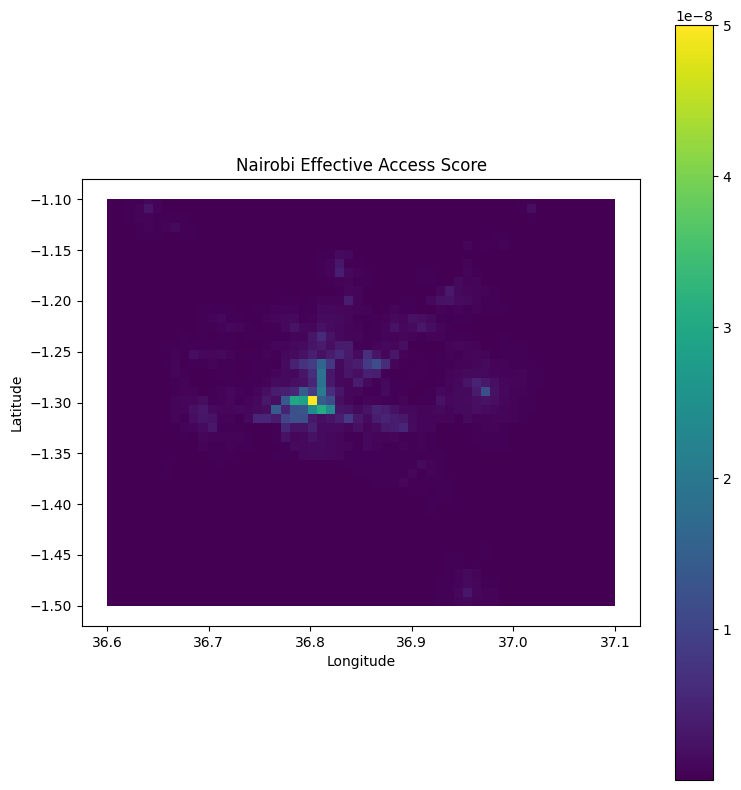

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

effective_access_wgs84 = effective_access.to_crs(CRS_WGS84)

effective_access_wgs84.plot(
    column="effective_access_score",
    ax=ax,
    cmap="viridis",
    legend=True,
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Effective Access Score")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "08_effective_access_score.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/08_healthcare_inequality_score.png


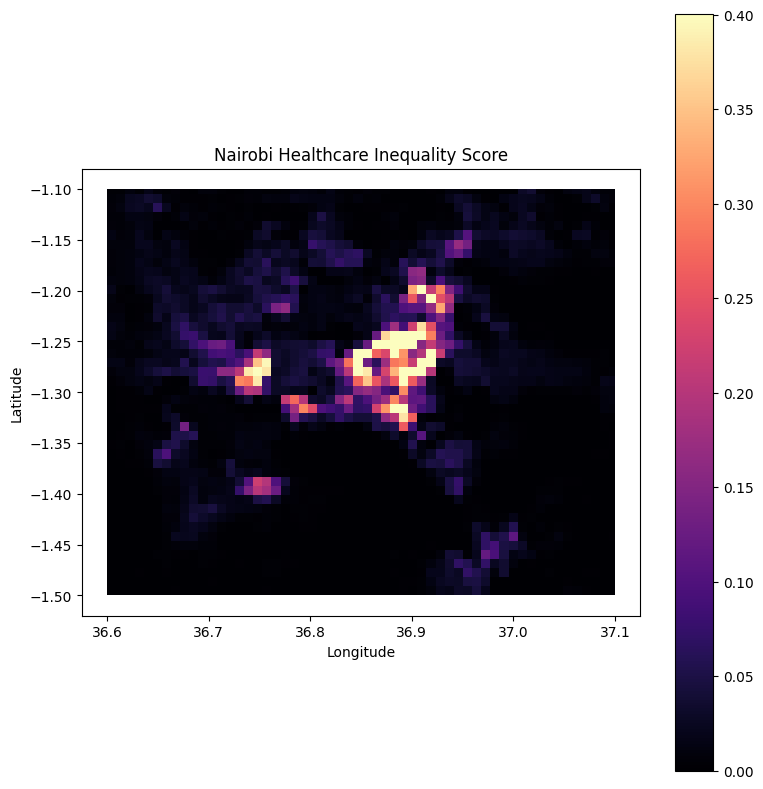

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

vmax = effective_access_wgs84["inequality_score"].quantile(0.99)

effective_access_wgs84.plot(
    column="inequality_score",
    ax=ax,
    cmap="magma",
    legend=True,
    linewidth=0,
    vmax=vmax
)

ax.set_title(f"{CITY_NAME} Healthcare Inequality Score")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "08_healthcare_inequality_score.png")
plt.show()

In [19]:
# --- BASELINE (distance-only model) ---

df = effective_access.copy()

# baseline access = multi_access_score (already computed earlier)
df["baseline_access"] = df["multi_access_score"]

# baseline inequality (distance-only)
df["baseline_inequality"] = df["population"] * (1 / (df["baseline_access"] + 1e-12))

# normalize both for comparison
df["baseline_ineq_norm"] = (
    (df["baseline_inequality"] - df["baseline_inequality"].min()) /
    (df["baseline_inequality"].max() - df["baseline_inequality"].min())
)

df["model_ineq_norm"] = (
    (df["inequality_score"] - df["inequality_score"].min()) /
    (df["inequality_score"].max() - df["inequality_score"].min())
)

print("Baseline comparison ready.")

Baseline comparison ready.


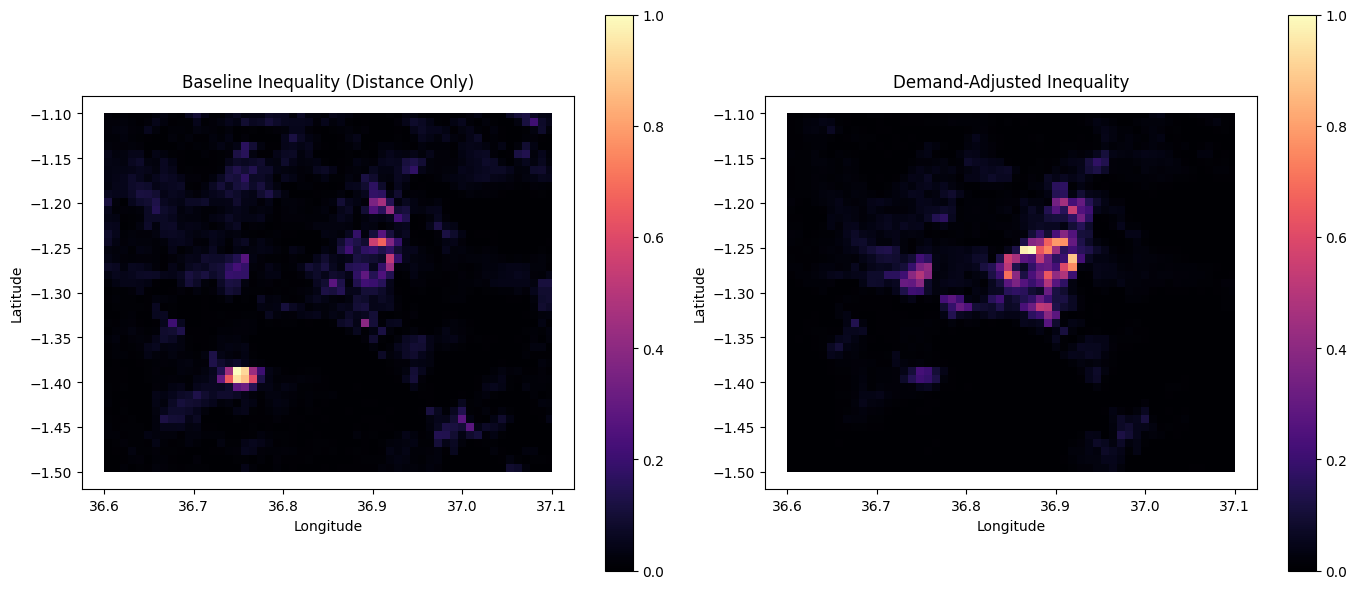

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_wgs84 = df.to_crs(CRS_WGS84)

# Baseline
df_wgs84.plot(
    column="baseline_ineq_norm",
    ax=axes[0],
    cmap="magma",
    linewidth=0,
    legend=True
)
axes[0].set_title("Baseline Inequality (Distance Only)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Your model
df_wgs84.plot(
    column="model_ineq_norm",
    ax=axes[1],
    cmap="magma",
    linewidth=0,
    legend=True
)
axes[1].set_title("Demand-Adjusted Inequality")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [14]:
# Hotspots: top 10 percent inequality cells
threshold_90 = effective_access["inequality_score"].quantile(0.90)

hotspots = effective_access[effective_access["inequality_score"] >= threshold_90].copy()

print("Hotspot threshold:", threshold_90)
print("Number of hotspot cells:", len(hotspots))

Hotspot threshold: 0.05643014081304379
Number of hotspot cells: 252


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/08_inequality_hotspots.png


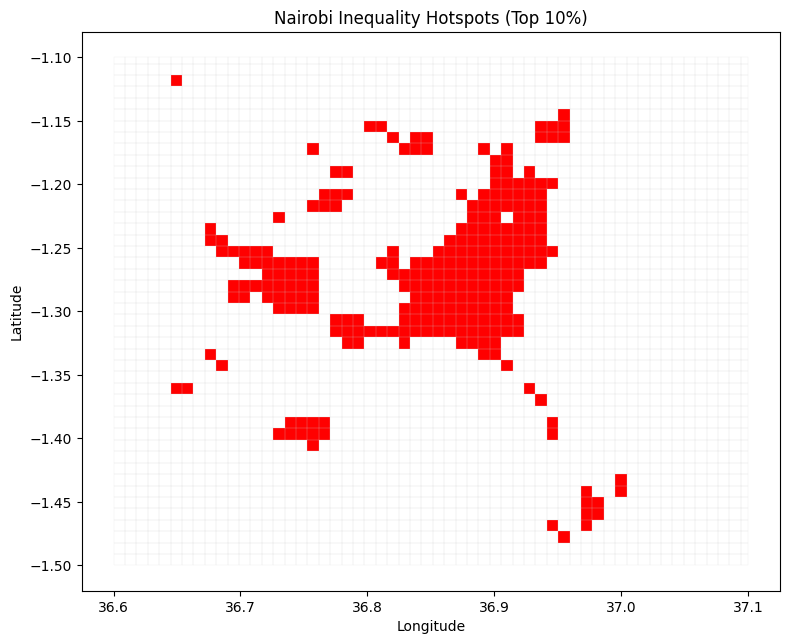

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

effective_access_wgs84.boundary.plot(ax=ax, color="lightgray", linewidth=0.1)

hotspots_wgs84 = hotspots.to_crs(CRS_WGS84)
hotspots_wgs84.plot(ax=ax, color="red", linewidth=0)

ax.set_title(f"{CITY_NAME} Inequality Hotspots (Top 10%)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "08_inequality_hotspots.png")
plt.show()

In [16]:
effective_access.to_parquet(FILES["effective_access"], index=False)
print("Saved effective access to:", FILES["effective_access"])

Saved effective access to: /Users/suvo/Projects/urban-healthcare/data/processed/effective_access.parquet


In [17]:
hotspots_path = Path(FILES["effective_access"]).parent / "inequality_hotspots.parquet"
hotspots.to_parquet(hotspots_path, index=False)
print("Saved hotspots to:", hotspots_path)

Saved hotspots to: /Users/suvo/Projects/urban-healthcare/data/processed/inequality_hotspots.parquet
